# Operational Workflow — Solcast Live + Forecast → SolarFarmer 3D
**Near-real-time and forecast weather data driving a SolarFarmer energy calculation (Workflow 1)**

---

This notebook demonstrates an **operational** use case: pulling the most recent satellite-derived
observations and short-range irradiance forecasts from Solcast, converting them to a SolarFarmer
weather file, and running an energy yield calculation against an existing set of API input files.

| Step | What happens |
|------|--------------|
| Weather retrieval | Solcast Live (last 12 h) + Forecast (next 36 h) |
| Parameters | `ghi`, `dhi`, `air_temp`, `wind_speed_10m` |
| Location | Fort Peck, Montana — Solcast unmetered site |
| Weather export | Combined dataset → SolarFarmer TSV via `sf.from_solcast()` |
| Energy calculation | SolarFarmer Workflow 1 — existing API files in `operational_usecase/` |
| Results | PVsyst-format time-series: POA irradiance, temperature, DC/AC/grid power |

**SolarFarmer SDK documentation:** https://dnv-opensource.github.io/solarfarmer-python-sdk/  
**SolarFarmer Workflow 1:** https://dnv-opensource.github.io/solarfarmer-python-sdk/getting-started/workflow-1-existing-api-files/  
**Solcast API documentation:** https://docs.solcast.com.au/

---
### Before you start
1. Obtain a [SolarFarmer API key](https://solarfarmer.dnv.com/) and set it as `SF_API_KEY`.
2. Obtain a [Solcast API key](https://toolkit.solcast.com.au/register) and set it as `SOLCAST_API_KEY`.
   - Windows: `set SF_API_KEY=your-key` and `set SOLCAST_API_KEY=your-key`
   - Mac/Linux: `export SF_API_KEY=your-key` and `export SOLCAST_API_KEY=your-key`
3. Create (if not already available) the `operational_usecase/` folder and place your SolarFarmer API files inside it:
   ```
   operational_usecase/
   ├── EnergyCalcInputs.json
   ├── module.PAN
   └── inverter.OND
   ```
   The weather TSV is written here automatically by this notebook.
4. Run each cell in order.

## 1. Setup & Configuration

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import solarfarmer as sf

# --- API keys ---
SF_API_KEY      = os.environ.get("SF_API_KEY",      "YOUR_SF_KEY_HERE")
SOLCAST_API_KEY = os.environ.get("SOLCAST_API_KEY", "YOUR_SOLCAST_KEY_HERE")

for name, key in [("SF_API_KEY", SF_API_KEY), ("SOLCAST_API_KEY", SOLCAST_API_KEY)]:
    status = "found" if "YOUR" not in key else "NOT SET — paste it above or export the env var"
    print(f"{name}: {status}")

SF_API_KEY: found
SOLCAST_API_KEY: found


## 2. Location — Fort Peck (Solcast Unmetered Site)

Fort Peck, Montana is one of Solcast's [unmetered locations](https://docs.solcast.com.au/#unmetered-locations).
API calls to unmetered coordinates do not consume quota — ideal for development and demonstrations.

| Parameter | Value |
|-----------|-------|
| Site | Fort Peck, Montana |
| Latitude | 48.31 °N |
| Longitude | −105.10 °E |

In [2]:
from solcast.unmetered_locations import UNMETERED_LOCATIONS

site = UNMETERED_LOCATIONS["Fort Peck"]
LATITUDE  = site["latitude"]
LONGITUDE = site["longitude"]

print(f"Site: Fort Peck")
print(f"Latitude:  {LATITUDE}°N")
print(f"Longitude: {LONGITUDE}°E")

Site: Fort Peck
Latitude:  48.30783°N
Longitude: -105.1017°E


## 3. Live Data — Last 12 Hours

The `live` endpoint provides satellite-derived observations continuously updated as imagery is processed.
We retrieve the last 12 hours at 5-minute resolution to capture recent conditions.

| Parameter | Description |
|-----------|-------------|
| `ghi` | Global Horizontal Irradiance (W/m²) |
| `dhi` | Diffuse Horizontal Irradiance (W/m²) |
| `air_temp` | Air temperature at 2 m (°C) |
| `wind_speed_10m` | Wind speed at 10 m (m/s) |

In [3]:
%%time
from solcast import live

PARAMETERS = ["ghi", "dhi", "air_temp", "wind_speed_10m"]
PERIOD = "PT5M"

live_data = live.radiation_and_weather(
    latitude=LATITUDE,
    longitude=LONGITUDE,
    output_parameters=PARAMETERS,
    hours=12,
    period=PERIOD,
    api_key=SOLCAST_API_KEY,
).to_pandas()

print(f"Live dataset:  {len(live_data)} records")
print(f"Date range:    {live_data.index[0]} → {live_data.index[-1]}")
live_data.tail()

Live dataset:  145 records
Date range:    2026-05-07 11:00:00+00:00 → 2026-05-06 23:00:00+00:00
CPU times: total: 0 ns
Wall time: 850 ms


,ghi,dhi,air_temp,wind_speed_10m
period_end,,,,
2026-05-06 23:20:00+00:00,481,70,13,4.3
2026-05-06 23:15:00+00:00,496,71,13,4.4
2026-05-06 23:10:00+00:00,510,72,13,4.4
2026-05-06 23:05:00+00:00,525,73,13,4.4
2026-05-06 23:00:00+00:00,539,74,13,4.5


## 4. Forecast Data — Next 36 Hours

The `forecast` endpoint returns irradiance and weather predictions up to 14 days ahead.
Short-range forecasts (~4 h) are satellite-nowcast based; beyond that, NWP models take over.
We retrieve the next 36 hours at 5-minute resolution.

In [4]:
%%time
from solcast import forecast

forecast_data = forecast.radiation_and_weather(
    latitude=LATITUDE,
    longitude=LONGITUDE,
    output_parameters=PARAMETERS,
    hours=36,
    period=PERIOD,
    api_key=SOLCAST_API_KEY,
).to_pandas()

print(f"Forecast dataset: {len(forecast_data)} records")
print(f"Date range:       {forecast_data.index[0]} → {forecast_data.index[-1]}")
forecast_data.head()

Forecast dataset: 433 records
Date range:       2026-05-07 11:00:00+00:00 → 2026-05-08 23:00:00+00:00
CPU times: total: 0 ns
Wall time: 974 ms


,ghi,dhi,air_temp,wind_speed_10m
period_end,,,,
2026-05-07 11:00:00+00:00,0,0,2,2.1
2026-05-07 11:05:00+00:00,0,0,2,2.1
2026-05-07 11:10:00+00:00,0,0,2,2.1
2026-05-07 11:15:00+00:00,0,0,2,2.1
2026-05-07 11:20:00+00:00,0,0,2,2.1


## 5. Plot — Live Observations and Forecast

The dashed vertical line marks the boundary between **past observations** (Live, left)
and **future predictions** (Forecast, right).

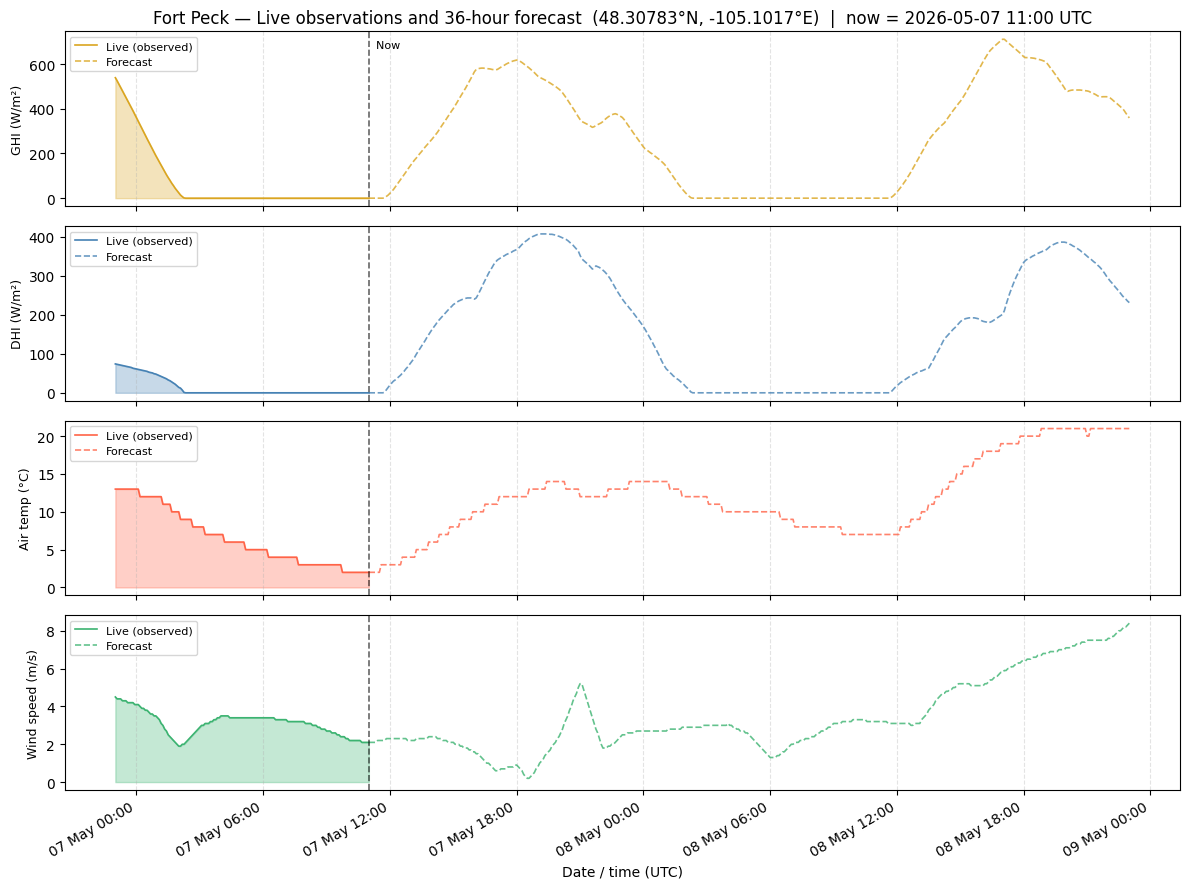

In [5]:
# The boundary between live and forecast — last timestamp of observed data
now_utc = live_data.sort_index().last_valid_index()

PARAMS_PLOT = [
    ("ghi",            "GHI (W/m²)",        "goldenrod"),
    ("dhi",            "DHI (W/m²)",        "steelblue"),
    ("air_temp",       "Air temp (°C)",     "tomato"),
    ("wind_speed_10m", "Wind speed (m/s)",  "mediumseagreen"),
]

fig, axes = plt.subplots(len(PARAMS_PLOT), 1, figsize=(12, 9), sharex=True)

for ax, (col, ylabel, color) in zip(axes, PARAMS_PLOT):
    # Past: solid fill
    ax.fill_between(live_data.index, live_data[col], alpha=0.30, color=color)
    ax.plot(live_data.index, live_data[col], color=color, linewidth=1.2, label="Live (observed)")

    # Future: dashed line only
    ax.plot(forecast_data.index, forecast_data[col],
            color=color, linewidth=1.2, linestyle="--", alpha=0.80, label="Forecast")

    # Vertical separator
    ax.axvline(now_utc, color="black", linestyle="--", linewidth=1.2, alpha=0.6)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(axis="x", linestyle="--", alpha=0.35)

# Label the boundary on the top panel
ylim = axes[0].get_ylim()
axes[0].text(
    now_utc, ylim[1] * 0.95, "  Now",
    fontsize=8, color="black", va="top",
)

axes[0].set_title(
    f"Fort Peck — Live observations and 36-hour forecast  "
    f"({LATITUDE}°N, {LONGITUDE}°E)  |  now = {now_utc.strftime('%Y-%m-%d %H:%M UTC')}"
)
axes[-1].set_xlabel("Date / time (UTC)")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b %H:%M"))
fig.autofmt_xdate(rotation=30)

plt.tight_layout()
plt.show()

## 6. Combine & Export to SolarFarmer TSV

Concatenate the live and forecast DataFrames into a single continuous time series,
then convert it to SolarFarmer's TSV format with `sf.from_solcast()`.
Any overlap at the boundary is resolved by keeping the live (observed) value.

The weather file is written directly into the `operational_usecase/` folder so
SolarFarmer Workflow 1 can pick it up automatically.

In [6]:
# Merge live (past) and forecast (future), keeping observed values where they overlap
combined = (
    pd.concat([live_data, forecast_data])
    .sort_index()
    # keep first occurrence — live data is prepended so observed values win
    [lambda df: ~df.index.duplicated(keep="first")]
)

print(f"Combined dataset: {len(combined)} records")
print(f"Date range:       {combined.index[0]} → {combined.index[-1]}")

WEATHER_FILE = Path("operational_usecase") / "weather_fort_peck_operational.tsv"

# from_solcast() renames columns to SolarFarmer conventions and writes the TSV
sf.from_solcast(df=combined, output_path=WEATHER_FILE)

print(f"\nWeather file written: {WEATHER_FILE.resolve()}")

Combined dataset: 577 records
Date range:       2026-05-06 23:00:00+00:00 → 2026-05-08 23:00:00+00:00

Weather file written: C:\repos\pvpmc_usa_2026_dnv_apis\operational_usecase\weather_fort_peck_operational.tsv


## 7. SolarFarmer Workflow 1 — Energy Calculation

With the weather file in place, **Workflow 1** loads all input files from the
`operational_usecase/` folder and submits the calculation to the SolarFarmer API.

Expected folder contents before running this cell:

```
operational_usecase/
├── EnergyCalcInputs.json            # SolarFarmer API payload (from desktop or previous export)
├── module.PAN                        # Module specification
├── inverter.OND                      # Inverter specification
└── weather_fort_peck_operational.tsv # Written by the previous cell
```

> **Key concept:** Design your site layout once in SolarFarmer Desktop — define the
> tracker geometry, string configuration, and electrical topology — then export it to
> `EnergyCalcInputs.json` via *File → Export API files*. That JSON becomes a permanent
> artifact of your project: drop in a fresh weather file and the SDK reuses the same
> detailed design indefinitely, with no manual re-entry required.

### Site characteristics

A single-axis trackers site of 0.7 MWp, 5 inverters (each with a different slope-aware backtracking setting), around 1950 modules (81 trackers).

![Operational Site Layout](operational_usecase/OperationalSite_Layout.png)


In [7]:
%%time
INPUTS_FOLDER = Path("operational_usecase")

results = sf.run_energy_calculation(
    inputs_folder_path=INPUTS_FOLDER,
    project_id="fort-peck-operational",
    api_key=SF_API_KEY,
    print_summary=True,
    save_outputs=True,
    outputs_folder_path="operational_usecase/outputs"
)

-------------------------------------------------------
		General site data:
-------------------------------------------------------
Project name = fort-peck-operational
Location (latitude, longitude, altitude) = 48.30783°, -105.10170°, 633.8 m
2D/3D = 3D calculation
Mounting type = Single-axis trackers
AC capacity of system = 0.625 MW
DC capacity of system = 0.729 MW
Run in SolarFarmer API version 6.1.0
-------------------------------------------------------
    Annual Performance Summary (project year 1, 2026)
-------------------------------------  -------------
Average annual temperature             10.68°C
Horizontal irradiation                 11.04 kWh/m²
Irradiation on tilted plane            15.83 kWh/m²
Effective irradiation on tilted plane  15.28 kWh/m²
Energy yield                           13.49 kWh/kWp
Net energy                             9.84 MWh/year
Performance Ratio                      0.8522
-------------------------------------  -------------
CPU times: total: 0 n

c:\repos\pvpmc_usa_2026_dnv_apis\.venv\Lib\site-packages\solarfarmer\models\energy_calculation_results.py:1779: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["date"] = pd.to_datetime(data["date"], utc=True).dt.tz_localize(None)


## 8. SolarFarmer PVsyst Time-Series Results

`results.pvsyst_timeseries()` returns the full simulation time series in PVsyst column format.
We plot the five key operational channels:

| Column | Description |
|--------|-------------|
| `GlobEffTotal` | Effective in-plane (POA) irradiance (W/m²) |
| `TArray` | PV array temperature (°C) |
| `WindVel` | Wind speed (m/s) |
| `ShdLossTotal` | Global irradiance loss (W/m²) |
| `E_Grid` | Net site output at grid connection point (kWh) |

Available timeseries variables are:
- [SolarFarmer cloud time-series results files](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/CalcRef/OutputFiles/CloudTestingFiles.html)

In [8]:
# Option 1: Load from results object
ts = results.pvsyst_timeseries()

# Option 2: Load from saved CSV file (alternative if re-loading from saved outputs)
csv_file = Path("operational_usecase/outputs") / "PVsystResults.csv"
if csv_file.exists():
    ts = pd.read_csv(
        csv_file,
        sep=";",
        skiprows=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12],
        index_col=0,
        parse_dates=True,
        dayfirst=True,
        date_format="%d/%m/%y %H:%M",
    )
    print(f"Loaded from file: {csv_file}")
else:
    print(f"File not found: {csv_file} — using results.pvsyst_timeseries() instead")

print(f"Time-series records: {len(ts)}")
print(f"Available columns:   {list(ts.columns)}")
#ts.head()

Loaded from file: operational_usecase\outputs\PVsystResults.csv
Time-series records: 577
Available columns:   ['Alb_Inc', 'Albedo', 'Aux_Lss', 'AzSol', 'BackNearShd', 'BackShd', 'BeamHor', 'BeamInc', 'BmIncBk', 'DiffHor', 'DifSBak', 'DifSInc', 'E_Avail', 'E_Grid', 'EacOhmL', 'EArray', 'EArrMPP', 'EArrNom', 'EOutInv', 'ETrfLss', 'FShdBm', 'GIncLss', 'GlobBak', 'GlobEffTotal', 'GlobGndShd', 'GlobHor', 'GlobHrz', 'GlobHrzIAM', 'GlobHrzSlg', 'GlobInc', 'GlobShdTotal', 'HrzLoss', 'HSol', 'I_Boost', 'IAMLoss', 'IAMLossBak', 'IArray', 'IL_Night', 'IL_Oper', 'IL_Pmax', 'IL_Pmin', 'IL_Vmax', 'IL_Vmin', 'IL_Vshut', 'InvLoss', 'LIDLoss', 'MisLoss', 'ModBin', 'ModQual', 'OhmLoss', 'OP_Imax', 'OP_Oper', 'OP_Pmax', 'OP_Pmin', 'PhiAng', 'ShdALssTotal', 'ShdBLssTotal', 'ShdDLssTotal', 'ShdElec', 'ShdLossTotal', 'SlgLoss', 'SpctCor', 'T_Amb', 'TArray', 'TempLss', 'U_Boost', 'UArray', 'UnavLss', 'WindVel']


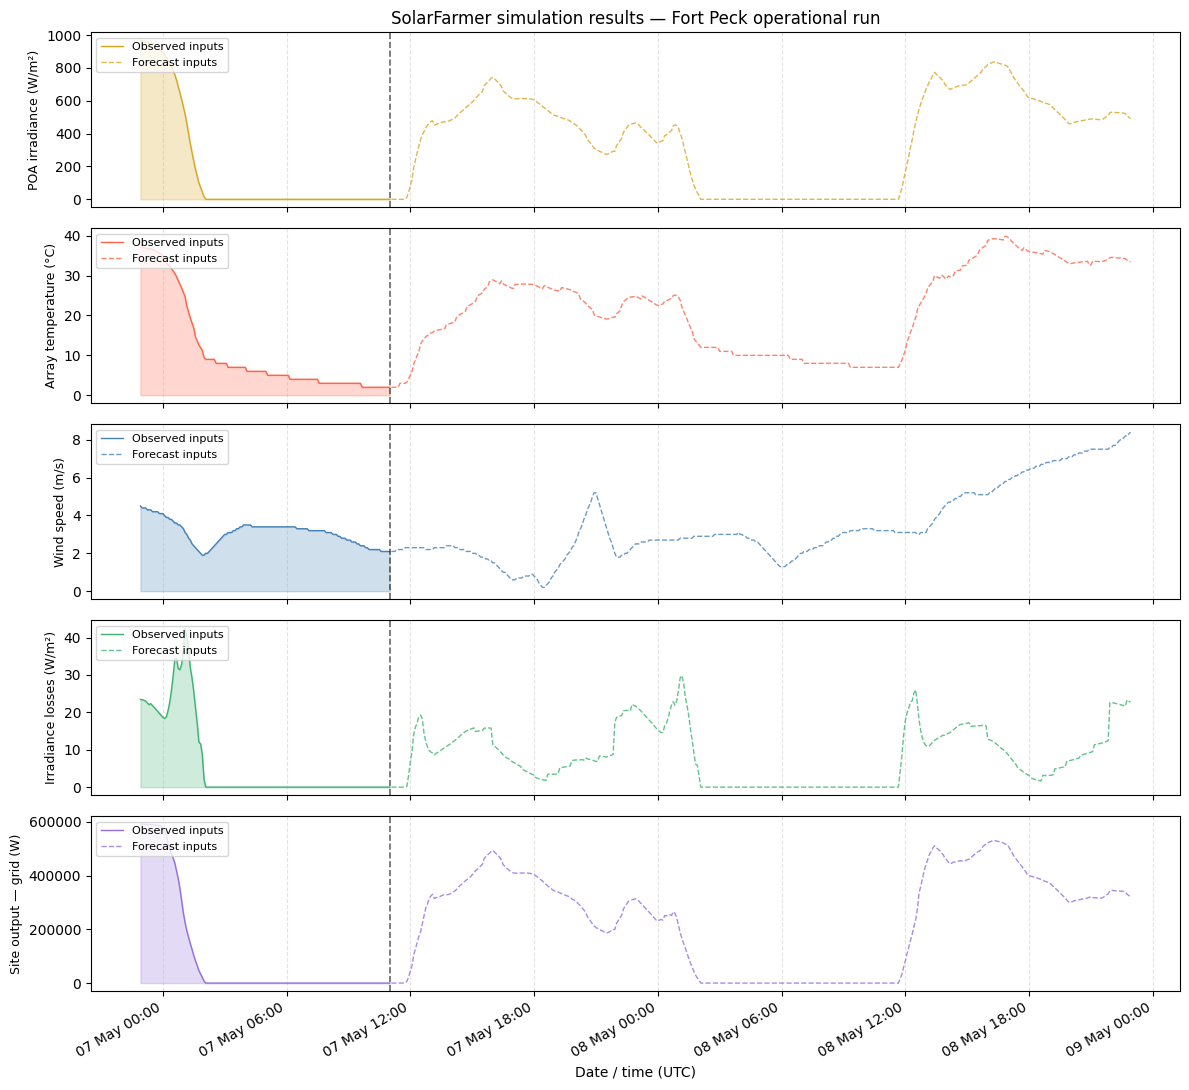

In [9]:
TS_CHANNELS = [
    ("GlobEffTotal", "POA irradiance (W/m²)",      "goldenrod"),
    ("TArray",       "Array temperature (°C)",      "tomato"),
    ("WindVel",       "Wind speed (m/s)",     "steelblue"),
    ("ShdLossTotal",  "Irradiance losses (W/m²)", "mediumseagreen"),
    ("E_Grid",       "Site output — grid (W)",    "mediumpurple"),
]

# now_utc is tz-aware; ts.index from the CSV is tz-naive — strip tz for comparison
split_ts = now_utc.tz_localize(None) if ts.index.tz is None else now_utc

ts_past     = ts[ts.index <= split_ts]
ts_forecast = ts[ts.index >  split_ts]

fig, axes = plt.subplots(len(TS_CHANNELS), 1, figsize=(12, 11), sharex=True)

for ax, (col, ylabel, color) in zip(axes, TS_CHANNELS):
    # Historical (observed weather inputs): solid fill + line
    ax.fill_between(ts_past.index, ts_past[col], alpha=0.25, color=color)
    ax.plot(ts_past.index, ts_past[col], color=color, linewidth=1.0, label="Observed inputs")

    # Forecast (predicted weather inputs): dashed line only
    ax.plot(ts_forecast.index, ts_forecast[col],
            color=color, linewidth=1.0, linestyle="--", alpha=0.80, label="Forecast inputs")

    ax.axvline(split_ts, color="black", linestyle="--", linewidth=1.2, alpha=0.6)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(axis="x", linestyle="--", alpha=0.35)

axes[0].set_title("SolarFarmer simulation results — Fort Peck operational run")
axes[-1].set_xlabel("Date / time (UTC)")

# Use AutoDateLocator for intelligent tick spacing on narrow time ranges
axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b %H:%M"))
fig.autofmt_xdate(rotation=30)

plt.tight_layout()
plt.show()


## 9. Summary

This notebook demonstrated a complete operational pipeline from live satellite data to simulated PV output:

| Step | Tool / Method |
|------|---------------|
| Locate unmetered site | `UNMETERED_LOCATIONS["Fort Peck"]` |
| Fetch live observations (12 h) | `live.radiation_and_weather(hours=12)` |
| Fetch short-range forecast (36 h) | `forecast.radiation_and_weather(hours=36)` |
| Visualise with past/future split | `ax.axvline(now_utc)` |
| Export to SolarFarmer weather file | `sf.from_solcast(df=combined, output_path=...)` |
| Run energy calculation (Workflow 1) | `sf.run_energy_calculation(inputs_folder_path=...)` |
| Inspect PVsyst time-series | `results.pvsyst_timeseries()` |

---
## Next steps

- Download a sample `EnergyCalcInputs.json` and equipment files from the [API tutorials](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/UserGuide/Tutorials/Tutorials.html). Update this notebook's inputs to match the coordinates and sample files.
- Replace sample json with your own project json and equipment files
- Parameterize this notebook with [**papermill**](https://papermill.readthedocs.io/en/latest/) or refactor into a python script and run it on a schedule using cron, systemd, or task scheduler for fully automated operational runs
- Feed the `E_Grid` time series or any other variable of interest into a dispatch or revenue-optimisation model

**Documentation & support:**  
https://dnv-opensource.github.io/solarfarmer-python-sdk/  
solarfarmer@dnv.com
